# Лабораторная работа №2 «Обнаружение аномалий и выбросов в данных»

In [1]:
import pandas as pd
from datetime import date
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import shapiro

df = pd.read_csv('../data/vgsales.csv')

## Задание 1. Загрузка и профилирование данных

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 16602 entries, 0 to 16601
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16602 non-null  int64  
 1   Name          16602 non-null  str    
 2   Platform      16602 non-null  str    
 3   Year          16331 non-null  float64
 4   Genre         16602 non-null  str    
 5   Publisher     16544 non-null  str    
 6   NA_Sales      16602 non-null  float64
 7   EU_Sales      16602 non-null  float64
 8   JP_Sales      16602 non-null  float64
 9   Other_Sales   16602 non-null  float64
 10  Global_Sales  16602 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16602.000000,16331.000000,16602.000000,16602.000000,16602.000000,16602.000000,16602.000000
mean,8298.651006,2006.406221,0.265477,0.147582,0.077944,0.048300,0.539599
std,4792.930447,5.828500,0.819863,0.512720,0.309680,0.189883,1.567027
min,1.000000,1980.000000,0.000000,0.000000,0.000000,-0.050000,0.010000
25%,4148.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8298.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12448.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


Анализ пропусков
В датасете присутствуют пропуски только в двух столбцах: Year (271 пропуск) и Publisher (58 пропусков). Остальные столбцы заполнены полностью.

Диапазоны значений
Значения Year охватывают период с 1980 по 2020 год (среднее ~2006). Продажи (NA_Sales, EU_Sales и др.) начинаются с 0, с максимумами до 41.49 (NA), 29.02 (EU), 10.22 (JP), 10.57 (Other) и 82.74 (Global). Rank логично идет от 1 до 16600.

Подозрительные экстремальные значения
Отрицательное значение в Other_Sales (-0.05) выглядит как ошибка, т.к. продажи не могут быть отрицательными. Максимумы продаж ожидаемы для топ-игр вроде GTA или Mario. Широкий разброс std (например, 1.57 для Global_Sales) указывает на сильное неравенство: большинство игр имеют низкие продажи (~0.01-0.5), несколько - хиты.

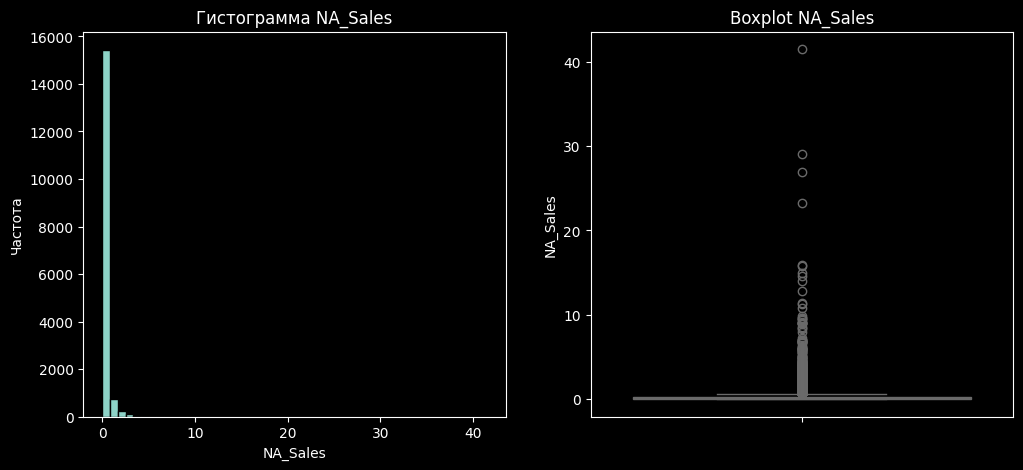

Вывод: 
1) гистограмма показывает сильную правую асимметрию (много игр с очень низким количеством продаж, хвост хитов);
2) boxplot показывает большое количество выбросов. Выбросы не являются ошибками, это игры-хиты


In [2]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df['NA_Sales'], bins=50, edgecolor='black')
plt.title('Гистограмма NA_Sales')
plt.xlabel('NA_Sales')
plt.ylabel('Частота')
plt.subplot(1,2,2)
sns.boxplot(y=df['NA_Sales'])
plt.title('Boxplot NA_Sales')
plt.show()
print("Вывод: \n1) гистограмма показывает сильную правую асимметрию (много игр с очень низким количеством продаж, хвост хитов);\n2) boxplot показывает большое количество выбросов. Выбросы не являются ошибками, это игры-хиты")

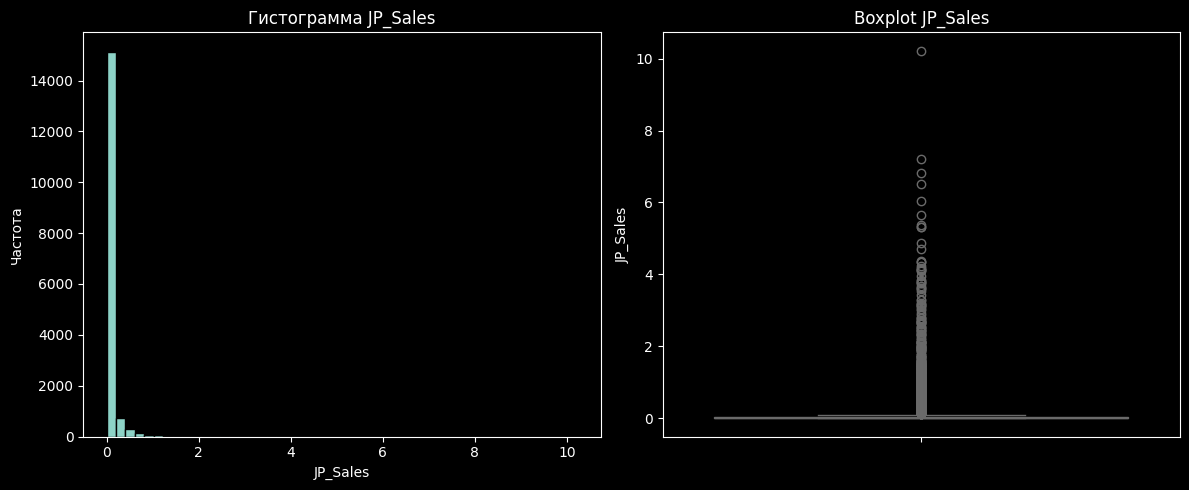

Вывод: 
1) гистограмма показывает сильную правую асимметрию (много игр с очень низким количеством продаж, хвост хитов);
2) boxplot показывает большое количество выбросов. Выбросы не являются ошибками, это игры-хиты


In [3]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df['JP_Sales'], bins=50, edgecolor='black')
plt.title('Гистограмма JP_Sales')
plt.xlabel('JP_Sales')
plt.ylabel('Частота')
plt.subplot(1,2,2)
sns.boxplot(y=df['JP_Sales'])
plt.title('Boxplot JP_Sales')
plt.tight_layout()
plt.show()

print("Вывод: \n1) гистограмма показывает сильную правую асимметрию (много игр с очень низким количеством продаж, хвост хитов);\n2) boxplot показывает большое количество выбросов. Выбросы не являются ошибками, это игры-хиты")

## Задание 2. Проверка нормальности распределения

1) Описательные характеристики

Признак: NA_Sales
  Среднее:            0.2655
  Медиана:            0.0800
  Ст. отклонение:     0.8199
  Асимметрия:         18.6502
  Эксцесс:            639.4593

Признак: JP_Sales
  Среднее:            0.0779
  Медиана:            0.0000
  Ст. отклонение:     0.3097
  Асимметрия:         11.1737
  Эксцесс:            193.1974

2) QQ-графики



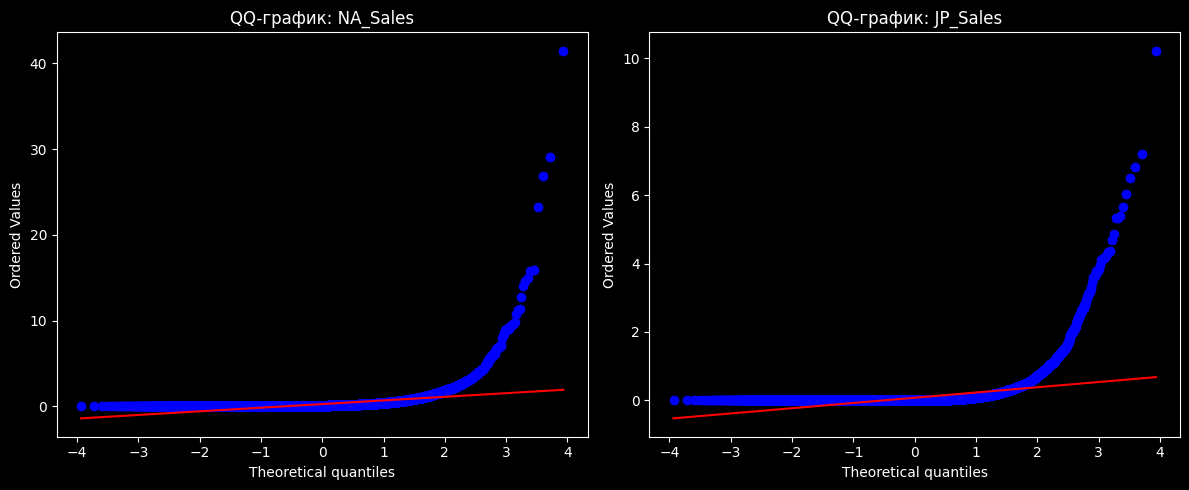

Вывод по QQ-графикам: точки заметно отклоняются от прямой, особенно в хвостах, значит распределение не является нормальным.

3) Критерий Шапиро–Уилка
H0: выборка подчиняется нормальному распределению.
H1: выборка не подчиняется нормальному распределению.
Уровень значимости: 0.05

Признак: NA_Sales
W-статистика: 0.2638
p-value:      9.760541e-89
Вывод: отвергаем H0, нормальность не подтверждается.

Признак: JP_Sales
W-статистика: 0.2569
p-value:      5.989494e-89
Вывод: отвергаем H0, нормальность не подтверждается.



In [8]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

cols = ['NA_Sales', 'JP_Sales']
alpha = 0.05

print('1) Описательные характеристики\n')

for c in cols:
    x = df[c].dropna()

    print(f'Признак: {c}')
    print(f'  Среднее:            {x.mean():.4f}')
    print(f'  Медиана:            {x.median():.4f}')
    print(f'  Ст. отклонение:     {x.std():.4f}')
    print(f'  Асимметрия:         {stats.skew(x):.4f}')
    print(f'  Эксцесс:            {stats.kurtosis(x):.4f}')
    print()

print('2) QQ-графики\n')

fig, axes = plt.subplots(1, len(cols), figsize=(12, 5))
for ax, c in zip(axes, cols):
    x = df[c].dropna()
    stats.probplot(x, dist='norm', plot=ax)
    ax.set_title(f'QQ-график: {c}')

plt.tight_layout()
plt.show()

print('Вывод по QQ-графикам: точки заметно отклоняются от прямой, особенно в хвостах, значит распределение не является нормальным.\n')

print('3) Критерий Шапиро–Уилка')
print('H0: выборка подчиняется нормальному распределению.')
print('H1: выборка не подчиняется нормальному распределению.')
print(f'Уровень значимости: {alpha}\n')

for c in cols:
    x = df[c].dropna()
    x_test = x.sample(n=min(len(x), 5000), random_state=0)

    stat, p = stats.shapiro(x_test)

    print(f'Признак: {c}')
    print(f'W-статистика: {stat:.4f}')
    print(f'p-value:      {p:.6e}')
    if p < alpha:
        print('Вывод: отвергаем H0, нормальность не подтверждается.')
    else:
        print('Вывод: нет оснований отвергнуть H0.')
    print()

## Задание 3. Обнаружение выбросов статистическими методами

JP_Sales: n=16602

1. Z-score (|Z| > 3)
Выбросов: 240 (1.4%)
13656


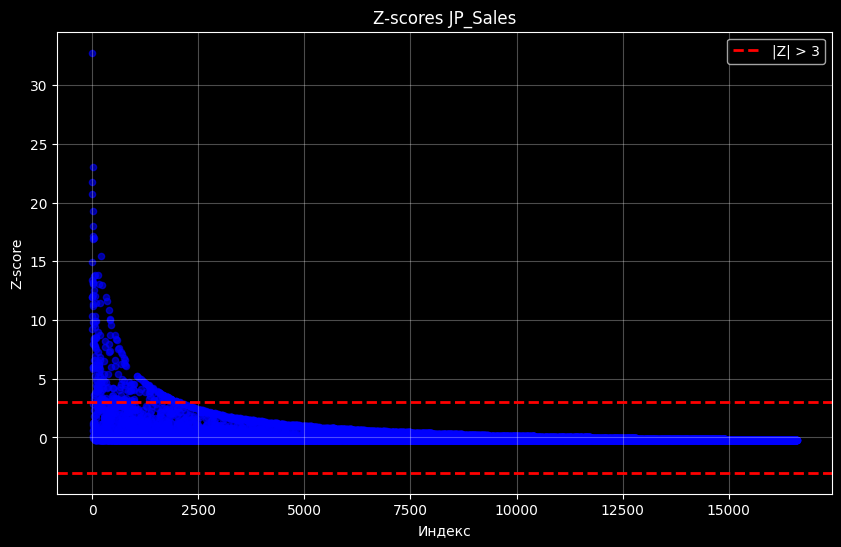


2. IQR (1.5×IQR)
Q1=0.000, Q3=0.040, IQR=0.040
Границы: [-0.060, 0.100]
Выбросов: 2427 (14.6%)


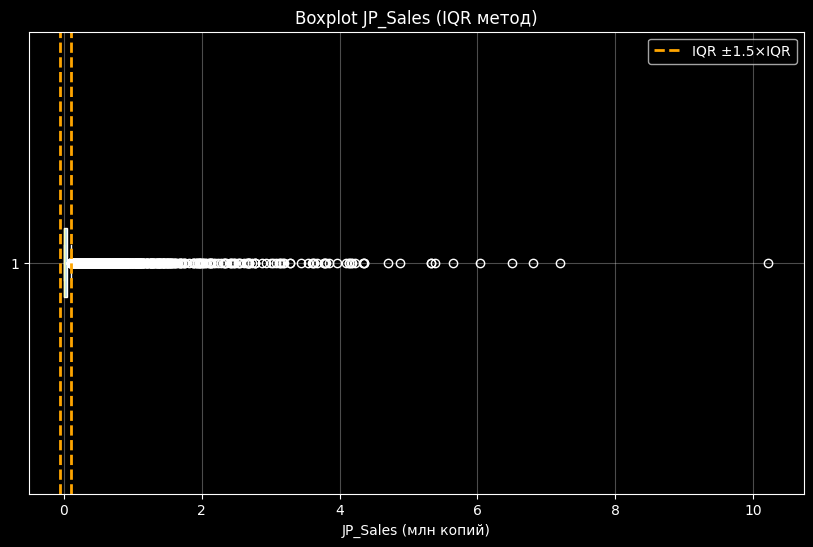

Сравнение
Z-score: 240 (1.4%)
IQR:     2427 (14.6%)

IQR нашёл в 10 раз больше выбросов
Причина: Z-score искажается нулями (Q1=0)
Вывод: для скошенных продаж → IQR точнее


In [24]:
jp_sales = df['JP_Sales'].dropna()
print(f'JP_Sales: n={len(jp_sales)}')

# 1. Z-score
z_scores = (jp_sales - jp_sales.mean()) / jp_sales.std()
outliers_z = jp_sales[abs(z_scores) > 3]
n_z = len(outliers_z)
print(f'\n1. Z-score (|Z| > 3)')
print(f'Выбросов: {n_z} ({n_z/len(jp_sales)*100:.1f}%)')

# ГРАФИК 1: Z-scores
plt.figure(figsize=(10, 6))
plt.scatter(range(len(z_scores)), z_scores, alpha=0.6, s=20, color='blue')
plt.axhline(3, color='red', ls='--', lw=2, label='|Z| > 3')
plt.axhline(-3, color='red', ls='--', lw=2)
plt.ylabel('Z-score')
plt.xlabel('Индекс')
plt.title('Z-scores JP_Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. IQR
Q1, Q3 = jp_sales.quantile([0.25, 0.75])
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers_iqr = jp_sales[(jp_sales < lower) | (jp_sales > upper)]
n_iqr = len(outliers_iqr)

print(f'\n2. IQR (1.5×IQR)')
print(f'Q1={Q1:.3f}, Q3={Q3:.3f}, IQR={IQR:.3f}')
print(f'Границы: [{lower:.3f}, {upper:.3f}]')
print(f'Выбросов: {n_iqr} ({n_iqr/len(jp_sales)*100:.1f}%)')

# ГРАФИК 2: Boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(jp_sales, vert=False, patch_artist=True,  boxprops=dict(facecolor='lightblue'))
plt.axvline(lower, color='orange', ls='--', lw=2, label='IQR ±1.5×IQR')
plt.axvline(upper, color='orange', ls='--', lw=2)
plt.xlabel('JP_Sales (млн копий)')
plt.title('Boxplot JP_Sales (IQR метод)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print('Сравнение')
print(f'Z-score: {n_z} ({n_z/len(jp_sales)*100:.1f}%)')
print(f'IQR:     {n_iqr} ({n_iqr/len(jp_sales)*100:.1f}%)')

print(f'\nIQR нашёл в 10 раз больше выбросов')
print(f'Причина: Z-score искажается нулями (Q1=0)')
print(f'Вывод: для скошенных продаж → IQR точнее')

## Задание 4. Метод локальной плотности

Данные: 16602 игр

k=5:
  Евклидово: 831 аномалий (5.0%)
  Манхэттенское: 830 аномалий (5.0%)


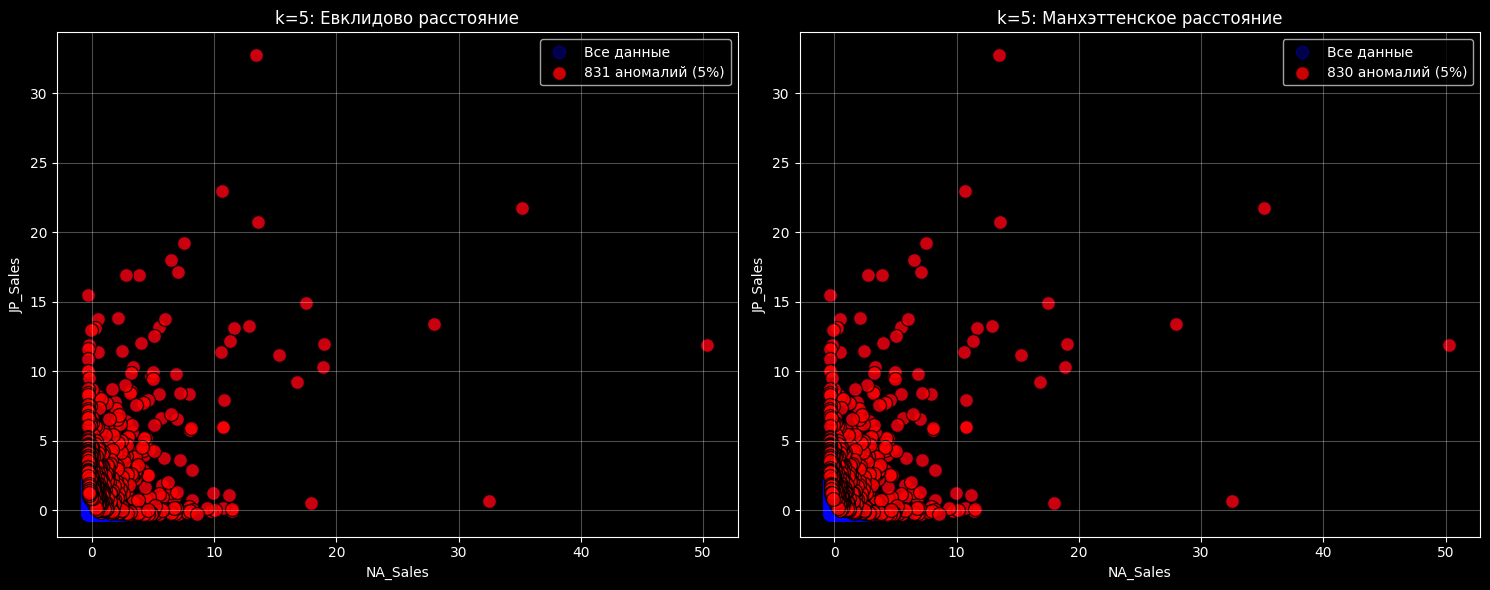


k=7:
  Евклидово: 831 аномалий (5.0%)
  Манхэттенское: 830 аномалий (5.0%)


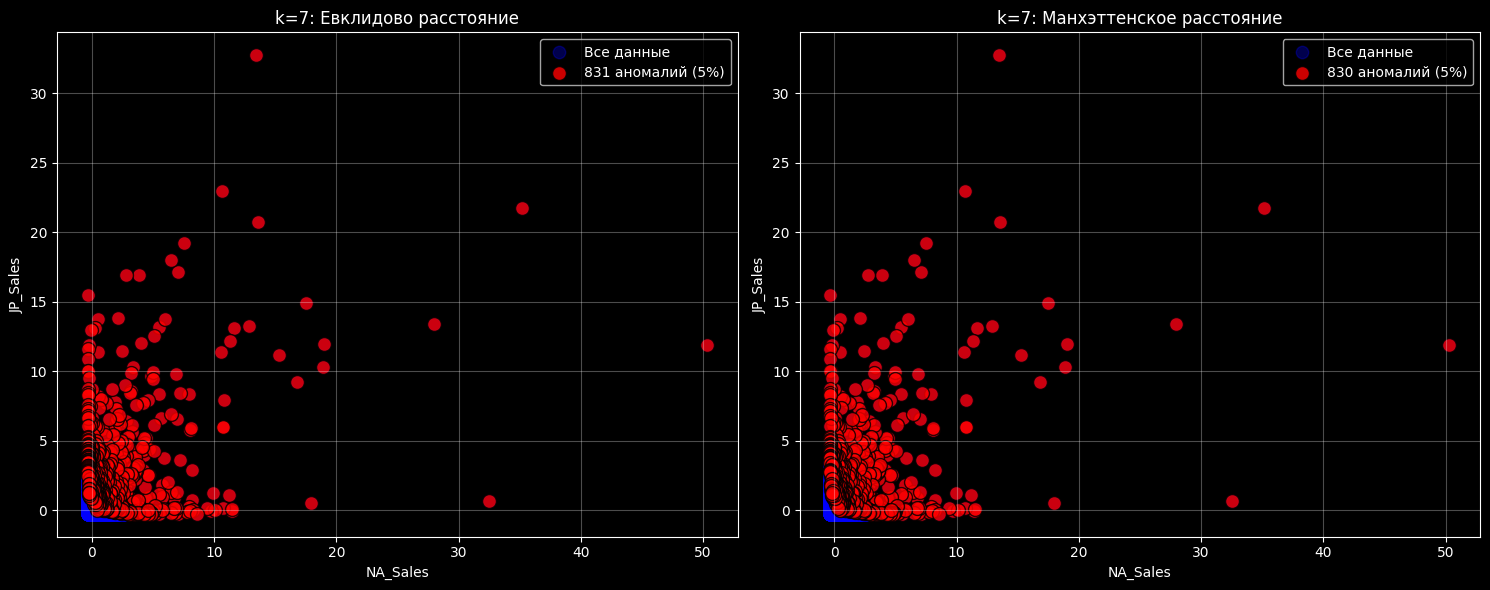


k=9:
  Евклидово: 831 аномалий (5.0%)
  Манхэттенское: 830 аномалий (5.0%)


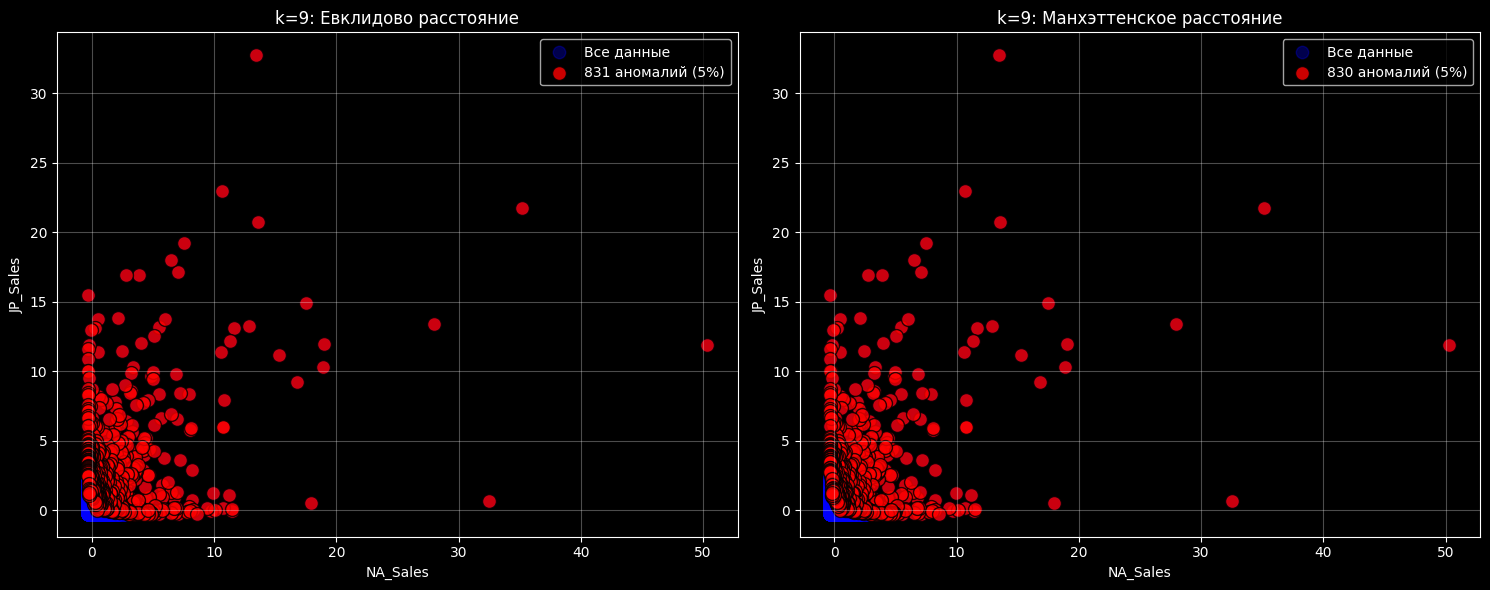


k=10:
  Евклидово: 831 аномалий (5.0%)
  Манхэттенское: 831 аномалий (5.0%)


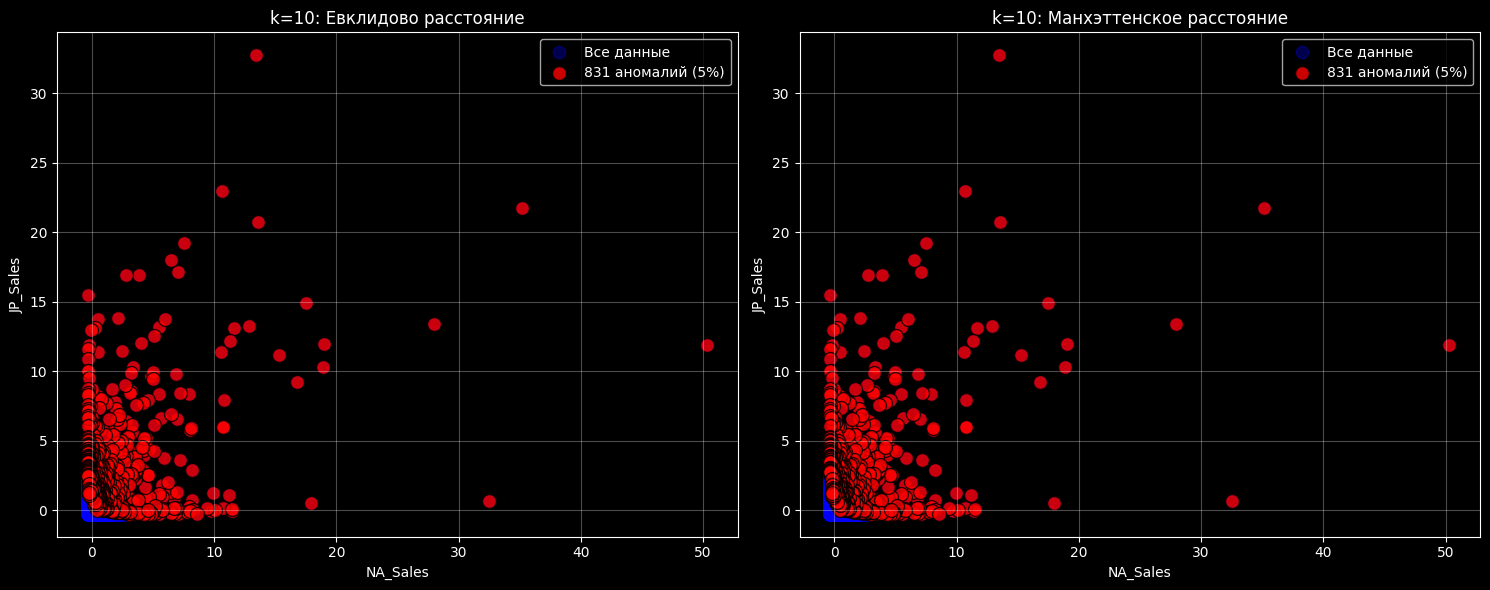


Для каждого k стабильно находится 5% аномалий
Евклидово расстояние и Манхэттенское дают практически одинаковые результаты


In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

X = df[['NA_Sales', 'JP_Sales']].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Данные: {len(X)} игр')

def detect_anomalies(k, data):
    print(f'\nk={k}:')

    # Евклидово
    nn_eucl = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(data)
    dist_eucl, _ = nn_eucl.kneighbors(data)
    mean_eucl = np.mean(dist_eucl[:,1:], axis=1)
    thresh_eucl = np.percentile(mean_eucl, 95)
    outliers_eucl = mean_eucl > thresh_eucl
    n_eucl = np.sum(outliers_eucl)

    # Манхэттен
    nn_manh = NearestNeighbors(n_neighbors=k+1, metric='manhattan').fit(data)
    dist_manh, _ = nn_manh.kneighbors(data)
    mean_manh = np.mean(dist_manh[:,1:], axis=1)
    thresh_manh = np.percentile(mean_manh, 95)
    outliers_manh = mean_manh > thresh_manh
    n_manh = np.sum(outliers_manh)

    print(f'  Евклидово: {n_eucl} аномалий ({n_eucl/len(data)*100:.1f}%)')
    print(f'  Манхэттенское: {n_manh} аномалий ({n_manh/len(data)*100:.1f}%)')

    figure, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    ax1.scatter(data[:,0], data[:,1], alpha=0.3, c='blue', label='Все данные', s=80)
    ax1.scatter(data[outliers_eucl,0], data[outliers_eucl,1],
                alpha=0.8, c='red', label=f'{n_eucl} аномалий (5%)', s=100, edgecolors='black')
    ax1.set_title(f'k={k}: Евклидово расстояние')
    ax1.set_xlabel('NA_Sales')
    ax1.set_ylabel('JP_Sales')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.scatter(data[:,0], data[:,1], alpha=0.3, c='blue', label='Все данные', s=80)
    ax2.scatter(data[outliers_manh,0], data[outliers_manh,1],
                alpha=0.8, c='red', label=f'{n_manh} аномалий (5%)', s=100, edgecolors='black')
    ax2.set_title(f'k={k}: Манхэттенское расстояние')
    ax2.set_xlabel('NA_Sales')
    ax2.set_ylabel('JP_Sales')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Запуск
for k in [5, 7, 9, 10]:
    detect_anomalies(k, X_scaled)

print('\nДля каждого k стабильно находится 5% аномалий')
print('Евклидово расстояние и Манхэттенское дают практически одинаковые результаты')